# Book Summary Annotation Analysis

This notebook analyzes human edits of AI-generated book summaries to identify recurring information that annotators add during post-editing.

The analysis focuses on **insertion edits**, which are normalized into reusable sentence templates, grouped into communicative functions using semantic clustering, and generalized into representative backbone sentences and templates through multiple sequence alignment. The resulting communicative functions are subsequently evaluated and analyzed across different book metadata, including genre, target audience, and fiction/non-fiction categories.

**Pipeline overview**

1. Load and preprocess the dataset.
2. Detect edit operations between automatic and human-edited summaries.
3. Extract and normalize insertion templates using named entity placeholders.
4. Filter and identify recurring insertion templates.
5. Embed templates and cluster them into communicative functions.
6. Select representative backbone sentences and derive generalized templates through multiple sequence alignment.
7. Evaluate communicative functions using support and average similarity.
8. Analyze communicative functions across genre and book metadata.
9. Summarize the discovered communicative functions and their representative backbone sentences.

## 0. Imports & Configuration

In [88]:
import json
import math
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regex as re
import spacy

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances
from spacy.lang.nl.stop_words import STOP_WORDS


# Dutch spaCy model
nlp = spacy.load("nl_core_news_lg")

# Dutch stopwords
dutch_stopwords = list(STOP_WORDS)

## 1. Data Loading

In [2]:
df = pd.read_csv("dataset_cleaned.tsv", sep="\t")
print(df.shape)
display(df.head())

(25917, 55)


/var/folders/c1/_vnm4tbd57174gws_3j9hz7h0000gn/T/ipykernel_28288/2004975598.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset_cleaned.tsv", sep="\t")


,isbn,baf,final_edit,automatic_output,intermediate_edit,FNF,VJ,agecat,title,subtitle,...,countries_published,known_works,product_form,debut,debut_year,author_status,title_status,professions,genres,blurb
0,9789461230485,mas_baf_processed_7,"Een reisgids voor Moravië, gelegen in het oost...",Een boek over het leven en de adel. Nuchter en...,NaN,NF,V,-,Moravië,Tsjechië,...,Nederland|Nieuw-Caledonië|Polen,NaN,Paperback,NaN,NaN,NaN,NaN,auteur,Verhandeling,Moravië Hier is het goede leven Het in het oos...
1,9789029095136,mas_baf_processed_8,‘De rivier’ is een historische roman over drie...,‘De rivier’ is een historische roman over drie...,NaN,F,V,-,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Een verbluffende, omvangrijke vertelling over ..."
2,9789044648683,mas_baf_processed_9,"Een knap gecomponeerde roman over identiteit, ...","Een knap gecomponeerde roman over identiteit, ...",NaN,F,V,-,Hoe hoog het water stijgt,NaN,...,Duitsland|Frankrijk|Verenigde Staten,NaN,Paperback,NaN,NaN,NaN,NaN,schrijver,Literaire fictie Roman,Finalist van de National Book Award Wenzel Gro...
3,9789022594735,mas_baf_processed_10,Een thriller van James Patterson over een myst...,Een thriller van James Patterson over het lege...,NaN,F,V,-,Oorverdovend,NaN,...,NaN,NaN,Paperback,The President is missing,2018.0,debutant,NaN,auteur|scenarioschrijver|acteur|televisieprodu...,Thriller|Detective,‘Als twee topthrillerschrijvers de krachten bu...
4,9789083171456,mas_baf_processed_11,Een boek over identiteit en het verdriet van a...,Een roman over identiteit en verlies. Het boek...,Een boek over identiteit en het verdriet van a...,F,V,-,821 mensen die er ook toe doen,NaN,...,NaN,NaN,Paperback,NaN,NaN,NaN,NaN,auteur,Literaire fictie Roman,Voor wie zichzelf wel eens verliest in het ver...


## 2. Text Preprocessing

Normalize the summaries to ensure consistent text processing. This includes standardizing whitespace and punctuation and providing a helper function for sentence segmentation using the Dutch spaCy model.

In [89]:
def preprocess_text(text):
    """Normalize whitespace and punctuation."""

    if pd.isna(text):
        return ""

    # Normalize whitespace
    text = " ".join(str(text).split())

    # Normalize quotation marks and dashes
    text = (
        text.replace("\u201c", '"')
            .replace("\u201d", '"')
            .replace("\u2018", "'")
            .replace("\u2019", "'")
            .replace("\u2013", "-")
            .replace("\u2014", "-")
    )

    return text


def split_sentences(text):
    """Split text into sentences using spaCy."""
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents]

## 3. Edit Detection

Detect differences between the automatic summary and the human-edited version.  
The comparison is first performed at sentence level. For replaced sentence blocks, a second word-level diff is applied to extract smaller edit spans.

Each detected edit is stored as a structured dictionary with an operation label:

- `insert`: text added by the annotator
- `delete`: text removed by the annotator
- `replace`: text changed from one span to another

This step is computationally expensive, so the resulting edit structures are later saved to a checkpoint file.

In [90]:
def get_edits(old_text, new_text, min_words=2):
    """
    Return structured edit spans between automatic_output and final_edit.

    The function first compares sentence sequences. For replaced sentence
    blocks, it performs a word-level diff to extract smaller changed spans.

    Output:
    [
        {"op": "insert", "old": "", "new": "..."},
        {"op": "delete", "old": "...", "new": ""},
        {"op": "replace", "old": "...", "new": "..."}
    ]
    """

    old_sentences = split_sentences(preprocess_text(old_text))
    new_sentences = split_sentences(preprocess_text(new_text))

    matcher = SequenceMatcher(None, old_sentences, new_sentences)
    edits = []

    def keep_span(span):
        words = span.split()
        return len(words) >= min_words

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():

        if tag == "insert":
            for sent in new_sentences[j1:j2]:
                if keep_span(sent):
                    edits.append({
                        "op": "insert",
                        "old": "",
                        "new": sent
                    })

        elif tag == "delete":
            for sent in old_sentences[i1:i2]:
                if keep_span(sent):
                    edits.append({
                        "op": "delete",
                        "old": sent,
                        "new": ""
                    })

        elif tag == "replace":
            old_chunk = " ".join(old_sentences[i1:i2])
            new_chunk = " ".join(new_sentences[j1:j2])

            old_words = old_chunk.split()
            new_words = new_chunk.split()

            word_matcher = SequenceMatcher(None, old_words, new_words)

            for wtag, wi1, wi2, wj1, wj2 in word_matcher.get_opcodes():

                if wtag == "replace":
                    old_span = " ".join(old_words[wi1:wi2])
                    new_span = " ".join(new_words[wj1:wj2])

                    if keep_span(old_span) or keep_span(new_span):
                        edits.append({
                            "op": "replace",
                            "old": old_span,
                            "new": new_span
                        })

                elif wtag == "insert":
                    new_span = " ".join(new_words[wj1:wj2])

                    if keep_span(new_span):
                        edits.append({
                            "op": "insert",
                            "old": "",
                            "new": new_span
                        })

                elif wtag == "delete":
                    old_span = " ".join(old_words[wi1:wi2])

                    if keep_span(old_span):
                        edits.append({
                            "op": "delete",
                            "old": old_span,
                            "new": ""
                        })

    return edits

### 3.1 Save Edit Checkpoint

Compute the structured edit operations for each summary pair and save them as a checkpoint. The edit lists are serialized as JSON to allow them to be reloaded without recomputing the diff analysis.

In [ ]:
df["edits"] = df.apply(
    lambda row: get_edits(
        row["automatic_output"],
        row["final_edit"]
    ),
    axis=1
)

df_save = df.copy()

# Serialize edit structures
df_save["edits"] = df_save["edits"].apply(json.dumps)

# Save checkpoint
df_save.to_csv(
    "df_with_edits.tsv",
    sep="\t",
    index=False
)

print("Checkpoint saved.")

Checkpoint saved.


### 3.2 Load Edit Checkpoint

Reload the precomputed edit operations from disk. This avoids rerunning the computationally expensive diff analysis during subsequent analyses.

In [91]:
# --- Load from checkpoint (skip re-running the diff step) ---
df = pd.read_csv("df_with_edits.tsv", sep="\t")

df["edits"] = df["edits"].apply(
    lambda x: json.loads(x)
    if isinstance(x, str) and x.strip()
    else []
)

/var/folders/c1/_vnm4tbd57174gws_3j9hz7h0000gn/T/ipykernel_30175/2572421618.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("df_with_edits.tsv", sep="\t")


### 3.3 Example of Edit Extraction

The following example illustrates how the edit detection procedure decomposes the differences between an AI-generated summary and its human-edited version into structured edit operations.

In [93]:
INSPECT_ROW = 6

print("=== Automatic summary ===\n")
print(df.loc[INSPECT_ROW, "automatic_output"])

print("\n=== Human-edited summary ===\n")
print(df.loc[INSPECT_ROW, "final_edit"])

print("\n=== Extracted edits ===\n")

for edit in df.loc[INSPECT_ROW, "edits"]:
    print(edit)

=== Automatic summary ===

Een boek over verdriet, troost en rouwverwerking. Voor een brede lezersgroep. Met illustraties. Huub Buijssen (1953) is een Nederlandse auteur.

=== Human-edited summary ===

Een boek over verdriet, troost en rouwverwerking. De auteur ontdekte dat er vijf talen van troost zijn: luisteren, er zijn voor de ander, iets geven, helpen en lichamelijke aanraking. Als je weet welke 'taal' de ander spreekt, en wat je zelf nodig hebt, wordt het makkelijker om steun te bieden of om hulp te vragen. Prettig en toegankelijk geschreven, voornamelijk in de je-vorm zodat de lezer zich direct aangesproken voelt. Voor een brede lezersgroep. Met illustraties. Huub Buijssen (1953) is psychogerontoloog, voormalig gezondheidszorgpsycholoog en klinisch psycholoog. Hij heeft meer dan veertig boeken geschreven.

=== Extracted edits ===

{'op': 'insert', 'old': '', 'new': 'De auteur ontdekte dat er vijf talen van troost zijn:'}
{'op': 'insert', 'old': '', 'new': 'luisteren, er zijn voo

## 4. Template Extraction and Normalization
Normalize inserted edit spans by replacing named entities with placeholder tokens while preserving the surrounding lexical context. Multi-token entities such as dates, people, locations, organizations, and titles are collapsed into single placeholders (e.g., `<DATE>`, `<PERSON>`, `<LOCATION>`, `<ORGANIZATION>`, `<TITLE>`).

This normalization reduces variation caused by entity names while retaining the sentence structure and wording, making recurring editorial patterns easier to identify in subsequent analyses.

In [94]:
SLOT_MAP = {
    "PERSON": "<PERSON>",
    "PER": "<PERSON>",
    "ORG": "<ORGANIZATION>",
    "GPE": "<LOCATION>",
    "LOC": "<LOCATION>",
    "DATE": "<DATE>",
    "TIME": "<TIME>",
    "MONEY": "<NUMBER>",
    "PERCENT": "<NUMBER>",
    "CARDINAL": "<NUMBER>",
    "ORDINAL": "<NUMBER>",
    "QUANTITY": "<NUMBER>",
    "PRODUCT": "<PRODUCT>",
    "WORK_OF_ART": "<TITLE>",
    "EVENT": "<EVENT>",
    "LAW": "<LAW>",
    "LANGUAGE": "<LANGUAGE>",
    "NORP": "<NATIONALITY>",
}


def normalize_template(text):
    """
    Normalize an insertion template by replacing named entities with
    placeholder tokens while preserving the surrounding lexical context.

    Example:
        "Geschikt voor lezers vanaf 12 jaar."
            ->
        "Geschikt voor lezers vanaf <DATE>."
    """

    if not isinstance(text, str) or not text.strip():
        return ""

    doc = nlp(text)

    pieces = []
    last_end = 0

    for ent in doc.ents:
        slot = SLOT_MAP.get(ent.label_, f"<{ent.label_}>")

        # Preserve text preceding the entity
        pieces.append(text[last_end:ent.start_char])

        # Replace the entity with its placeholder
        pieces.append(slot)

        last_end = ent.end_char

    # Append any remaining text
    pieces.append(text[last_end:])

    template = "".join(pieces)

    # Normalize whitespace introduced during replacement
    template = re.sub(r"\s+", " ", template).strip()

    return template

In [95]:
examples = [
    "Geschikt voor lezers vanaf ca. 12 jaar.",
    "Jan Jansen schreef meerdere boeken.",
    "Met foto's van Amsterdam."
]

for text in examples:
    print(text)
    print("→", normalize_template(text))
    print()

Geschikt voor lezers vanaf ca. 12 jaar.
→ Geschikt voor lezers vanaf ca. <DATE>.

Jan Jansen schreef meerdere boeken.
→ <PERSON> schreef meerdere boeken.

Met foto's van Amsterdam.
→ Met foto's van <LOCATION>.



### 4.1 Filter Insertion Templates
Extract normalized insertion templates and retain only complete, sentence-like insertions. Short fragments and incomplete phrases are discarded to reduce noise and ensure that subsequent analyses focus on meaningful editorial additions.

The filtering criteria require each template to:
- contain at least four words;
- end with sentence-final punctuation (`.`, `!`, or `?`).

In [96]:
def keep_template(template, min_words=4, require_sentence_end=True):
    """
    Return True if a normalized insertion template is suitable for analysis.

    A template is retained if it:
    - is a non-empty string;
    - contains at least `min_words` tokens;
    - optionally ends with sentence-final punctuation.
    """
    if not isinstance(template, str) or not template.strip():
        return False

    template = template.strip()
    words = template.split()

    if len(words) < min_words:
        return False

    if require_sentence_end and not template.endswith((".", "!", "?")):
        return False

    return True

### 4.2 Identify Recurring Templates

Count the normalized insertion templates and retain only those that occur at least twice. Rare templates are excluded to reduce sparsity and focus the subsequent embedding and clustering analyses on recurring editorial patterns.

In [97]:
insert_rows = []

for row_id, edits in df["edits"].items():
    for edit_id, edit in enumerate(edits):

        if not isinstance(edit, dict):
            continue

        if edit.get("op") != "insert":
            continue

        raw_text = edit.get("new", "")
        template = normalize_template(raw_text)

        if not keep_template(template):
            continue

        insert_rows.append({
            "row_id": row_id,
            "edit_id": edit_id,
            "raw_text": raw_text,
            "template": template,
            "genres": df.loc[row_id, "genres"] if "genres" in df.columns else None,
        })

insert_df = pd.DataFrame(insert_rows)

print(f"Retained insertion occurrences: {len(insert_df):,}")
display(insert_df.head())

Retained insertion occurrences: 17,739


,row_id,edit_id,raw_text,template,genres
0,6,1,"luisteren, er zijn voor de ander, iets geven, ...","luisteren, er zijn voor de ander, iets geven, ...",Verhandeling
1,6,2,"Als je weet welke 'taal' de ander spreekt, en ...","Als je weet welke 'taal' de ander spreekt, en ...",Verhandeling
2,6,3,"Prettig en toegankelijk geschreven, voornameli...","Prettig en toegankelijk geschreven, voornameli...",Verhandeling
3,11,0,In een donker dorp in een dal slijt Simone haa...,In een donker dorp in een dal slijt <PERSON> h...,Literaire fictie Roman
4,15,5,Bevat expliciete beschrijvingen van seksuele e...,Bevat expliciete beschrijvingen van seksuele e...,Lit. non-fic overig


In [98]:
MIN_TEMPLATE_COUNT = 2

template_counts = Counter(insert_df["template"])

common_df = (
    pd.DataFrame(
        [
            (template, count)
            for template, count in template_counts.items()
            if count >= MIN_TEMPLATE_COUNT
        ],
        columns=["template", "count"]
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print(f"All insertion occurrences : {len(insert_df):,}")
print(f"Unique templates          : {len(template_counts):,}")
print(f"Recurring templates       : {len(common_df):,}")

display(common_df.head(100))

All insertion occurrences : 17,739
Unique templates          : 15,813
Recurring templates       : 606


,template,count
0,Geschikt voor lezers vanaf ca. <DATE>.,102
1,Geschikt voor een brede tot literaire lezersgr...,65
2,Geschikt om voor te lezen vanaf ca. <DATE>.,49
3,Voor een breed tot literair lezerspubliek.,45
4,Voor een brede tot literaire lezersgroep.,42
...,...,...
95,Zijn roman 'Alleen met de goden' werd bekroond...,5
96,Helder en informatief geschreven.,5
97,Met lieflijke gekleurde illustraties.,5
98,Hij schreef een klein aantal boeken.,5


## 5. Template Embedding and Clustering

Embed the recurring normalized templates using a multilingual SentenceTransformer model. The resulting sentence embeddings are clustered with HDBSCAN to identify groups of semantically similar insertion templates.

HDBSCAN is used because it automatically determines the number of clusters and can identify templates that do not belong to any coherent group as noise. In subsequent sections, the discovered clusters are interpreted and assigned communicative function labels.

In [99]:
model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

common_embeddings = model.encode(
    common_df["template"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64
)

Batches: 100%|██████████| 10/10 [00:06<00:00,  1.63it/s]


In [100]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=1,
    metric="euclidean",
    cluster_selection_method="eom"
)

common_df["hdb_cluster"] = clusterer.fit_predict(common_embeddings)

n_clusters = common_df.loc[
    common_df["hdb_cluster"] != -1,
    "hdb_cluster"
].nunique()

n_noise = (common_df["hdb_cluster"] == -1).sum()

print(f"Clusters discovered : {n_clusters}")
print(f"Noise templates      : {n_noise}")

Clusters discovered : 15
Noise templates      : 179


### 5.1 Cluster Statistics

Summarize the discovered clusters by the total number of template occurrences they contain. This provides an initial indication of which recurring insertion patterns are most prevalent.

In [101]:
cluster_support = (
    common_df.loc[common_df["hdb_cluster"] != -1]
    .groupby("hdb_cluster", as_index=False)["count"]
    .sum()
    .rename(columns={"count": "support"})
    .sort_values("support", ascending=False)
)

cluster_support["support_pct"] = (
    cluster_support["support"] /
    cluster_support["support"].sum()
)

display(cluster_support)

,hdb_cluster,support,support_pct
13,13,470,0.224237
12,12,448,0.213740
5,5,321,0.153149
10,10,225,0.107347
11,11,130,0.062023
3,3,117,0.055821
4,4,103,0.049141
2,2,90,0.042939
7,7,58,0.027672
9,9,42,0.020038


### 5.2 Inspect Clusters

Inspect the most frequent templates within each cluster to interpret the discovered semantic groups. These representative templates are subsequently used to assign communicative function labels.

In [102]:
def inspect_hdb_cluster(cluster_id, n=3):
    group = (
        common_df[common_df["hdb_cluster"] == cluster_id]
        .sort_values("count", ascending=False)
    )

    print("=" * 100)
    print(f"Cluster {cluster_id}")
    print(f"Unique templates: {len(group)}")
    print(f"Support: {group['count'].sum()}")
    print()

    for _, row in group.head(n).iterrows():
        print(f"{row['count']:>5} | {row['template']}")

    print()


for cluster_id in sorted(common_df["hdb_cluster"].unique()):
    if cluster_id == -1:
        continue

    inspect_hdb_cluster(cluster_id, n=3)

Cluster 0
Unique templates: 5
Support: 13

    4 | In deze serie zijn alle <NUMBER> woorden uit de <FAC> <TITLE> vmbo verwerkt, gemiddeld tachtig woorden per deel. Deze woorden staan in een woordenlijst achterin het boek.
    3 | De volledige woordenlijst schooltaalwoorden vmbo bevat <NUMBER> woorden en is samengesteld door het <ORGANIZATION>.
    2 | Geschikt voor leerkrachten en begeleiders.

Cluster 1
Unique templates: 5
Support: 10

    2 | Geschikt voor beginnende lezers op AVI-niveau M4.
    2 | AVI-Start. Voor beginnende lezers vanaf ca. <DATE>.
    2 | Geschikt voor lezers op AVI-niveau E5 van <DATE>, die lezen moeilijk of saai vinden.

Cluster 2
Unique templates: 18
Support: 90

   16 | Ze schreef meerdere boeken.
   13 | Hij schreef meerdere boeken.
    7 | Ze schreef vele boeken.

Cluster 3
Unique templates: 20
Support: 117

   22 | Het boek bevat scènes met expliciet geweld.
   14 | Bevat scènes met expliciet geweld.
   12 | Het boek bevat scènes met expliciete seks.

Clust

### 5.3 Assign Communicative Function Labels

Based on manual inspection of the highest-frequency templates in each cluster, assign each cluster a communicative function label. These labels describe the type of information inserted by annotators, such as reading age, visual material, author background, or writing style.

In [103]:
cluster_function_map = {
    0: "educational_material",
    1: "avi_reading_level",
    2: "author_track_record",
    3: "content_warning",
    4: "author_identity",
    5: "reading_age",
    6: "paratext",
    7: "target_audience",
    8: "story_context",
    9: "series_information",
    10: "literary_readership",
    11: "advanced_readership",
    12: "writing_style",
    13: "visual_material",
    14: "maps_and_cartography",
}
common_df["function"] = (
    common_df["hdb_cluster"]
    .map(cluster_function_map)
)

In [104]:
# Map communicative function labels back to insertion occurrences
insert_df = insert_df.merge(
    common_df[["template", "function"]],
    on="template",
    how="left"
)

## 6. Backbone Sentence Selection and Template Generalization

For each communicative function, select a representative backbone sentence. The backbone is defined as the cluster medoid: the template whose embedding is closest, on average, to all other templates in the same function.

These backbone sentences provide readable representatives of each communicative function and are later used as anchors for generalized template extraction.

In [105]:
def get_function_medoid(function_label):
    """
    Return the medoid (most representative template) for a communicative
    function based on cosine distance in the embedding space.
    """
    group = common_df[common_df["function"] == function_label]

    idx = group.index.to_list()
    X = common_embeddings[common_df.index.get_indexer(idx)]

    # Pairwise cosine distances within the function
    D = cosine_distances(X)

    # Template with the smallest total distance to all others
    medoid_pos = np.argmin(D.sum(axis=1))
    medoid_idx = idx[medoid_pos]

    return common_df.loc[medoid_idx, "template"]


for function in sorted(common_df["function"].dropna().unique()):
    print("=" * 100)
    print(f"Function : {function}")
    print(f"Backbone : {get_function_medoid(function)}")
    print()

Function : advanced_readership
Backbone : Met name geschikt voor een geoefend lezerspubliek.

Function : author_identity
Backbone : <PERSON> (<DATE>) is een <NATIONALITY> schrijver.

Function : author_track_record
Backbone : Ze schreef meerdere boeken.

Function : avi_reading_level
Backbone : Geschikt voor beginnende lezers vanaf ca. <DATE> op AVI-niveau M3.

Function : content_warning
Backbone : Het boek bevat scènes met expliciete seks en expliciet geweld.

Function : educational_material
Backbone : In deze serie zijn alle <NUMBER> woorden uit de <FAC> <TITLE> vmbo verwerkt, gemiddeld tachtig woorden per deel. Deze woorden staan in een woordenlijst achterin het boek.

Function : literary_readership
Backbone : Met name geschikt voor een literair lezerspubliek.

Function : maps_and_cartography
Backbone : Met een zwart-witkaart van het fictieve gebied.

Function : paratext
Backbone : Voor de lezers van <PERSON>, <PERSON> en <PERSON>.

Function : reading_age
Backbone : Geschikt voor leze

### 6.1 Pairwise Template Alignment
Tokenize each template and align it to the corresponding backbone sentence using pairwise sequence alignment. The alignment records token matches, substitutions, insertions, and deletions relative to the backbone.

In [106]:
def tokenize_template(template):
    """
    Tokenize a normalized template while keeping slot placeholders intact.
    """
    return re.findall(
        r"<[^>]+>|\w+|[^\w\s]",
        template,
        flags=re.UNICODE
    )

In [107]:
def align_to_backbone(backbone_tokens, template_tokens):
    """
    Align one tokenized template to a tokenized backbone using difflib.

    Returns alignment records containing:
    - operation type
    - backbone index
    - backbone token
    - template token
    """
    matcher = SequenceMatcher(None, backbone_tokens, template_tokens)
    aligned = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():

        if tag == "equal":
            for bi, token in zip(range(i1, i2), template_tokens[j1:j2]):
                aligned.append({
                    "type": "match",
                    "backbone_index": bi,
                    "backbone_token": backbone_tokens[bi],
                    "template_token": token,
                })

        elif tag == "replace":
            backbone_positions = list(range(i1, i2))
            replacement_tokens = template_tokens[j1:j2]
            max_len = max(len(backbone_positions), len(replacement_tokens))

            for k in range(max_len):
                if k < len(backbone_positions):
                    bi = backbone_positions[k]
                    aligned.append({
                        "type": "replace",
                        "backbone_index": bi,
                        "backbone_token": backbone_tokens[bi],
                        "template_token": replacement_tokens[k]
                        if k < len(replacement_tokens)
                        else None,
                    })
                else:
                    aligned.append({
                        "type": "insert",
                        "backbone_index": i2,
                        "backbone_token": None,
                        "template_token": replacement_tokens[k],
                    })

        elif tag == "delete":
            for bi in range(i1, i2):
                aligned.append({
                    "type": "delete",
                    "backbone_index": bi,
                    "backbone_token": backbone_tokens[bi],
                    "template_token": None,
                })

        elif tag == "insert":
            for token in template_tokens[j1:j2]:
                aligned.append({
                    "type": "insert",
                    "backbone_index": i1,
                    "backbone_token": None,
                    "template_token": token,
                })

    return aligned

In [108]:
example_function = "reading_age"

backbone = get_function_medoid(example_function)
example_template = (
    common_df[common_df["function"] == example_function]
    .sort_values("count", ascending=False)
    .iloc[1]["template"]
)

pd.DataFrame(
    align_to_backbone(
        tokenize_template(backbone),
        tokenize_template(example_template)
    )
)

,type,backbone_index,backbone_token,template_token
0,match,0,Geschikt,Geschikt
1,insert,1,None,om
2,match,1,voor,voor
3,replace,2,lezers,te
4,insert,3,None,lezen
5,match,3,vanaf,vanaf
6,match,4,ca,ca
7,match,5,.,.
8,match,6,<DATE>,<DATE>
9,match,7,.,.


### 6.2 Construct Alignment Columns

Stack the pairwise alignments so that every backbone token corresponds to one alignment column. Each column aggregates the observed tokens across all templates, weighted by their frequency.

In [109]:
def build_alignment_columns(function_label):
    """
    Align all templates in a function to the function medoid and stack
    aligned tokens into backbone-indexed columns.

    Template counts are used as weights, so frequent templates contribute
    proportionally more to the alignment columns.
    """
    group = common_df[common_df["function"] == function_label].copy()

    backbone = get_function_medoid(function_label)
    backbone_tokens = tokenize_template(backbone)

    columns = defaultdict(list)
    insertion_columns = defaultdict(list)

    for _, row in group.iterrows():
        template_tokens = tokenize_template(row["template"])
        weight = int(row["count"])

        aligned = align_to_backbone(backbone_tokens, template_tokens)

        for item in aligned:
            backbone_index = item["backbone_index"]
            template_token = item["template_token"]

            if item["type"] == "insert":
                insertion_columns[backbone_index].extend(
                    [template_token] * weight
                )
            else:
                columns[backbone_index].extend(
                    [template_token] * weight
                )

    return {
        "function": function_label,
        "backbone": backbone,
        "backbone_tokens": backbone_tokens,
        "columns": columns,
        "insertion_columns": insertion_columns,
    }

### 6.3 Derive Generalized Templates

Convert the alignment columns into generalized templates using frequency thresholds. Frequently occurring tokens become fixed elements, multiple common tokens become alternations, and frequently omitted elements are marked as optional.

In [110]:
def summarize_alignment_column(
    values,
    fixed_threshold=0.70,
    optional_threshold=0.30,
    max_alternatives=3
):
    """
    Convert one alignment column into a template element.

    - If one token dominates, keep it as fixed.
    - Otherwise, list the most common alternatives.
    - If many values are missing, mark the element as optional.
    """
    total = len(values)

    if total == 0:
        return None

    counts = Counter(values)
    missing = counts.get(None, 0)

    non_missing = {
        token: count
        for token, count in counts.items()
        if token is not None
    }

    if not non_missing:
        return None

    token_counts = Counter(non_missing)
    top_token, top_count = token_counts.most_common(1)[0]
    top_ratio = top_count / total

    if top_ratio >= fixed_threshold:
        part = top_token
    else:
        alternatives = [
            token
            for token, _ in token_counts.most_common(max_alternatives)
        ]
        part = "(" + "|".join(alternatives) + ")"

    missing_ratio = missing / total

    if missing_ratio >= optional_threshold:
        part = "[" + part + "]"

    return part

In [111]:
def derive_template_from_columns(
    function_label,
    fixed_threshold=0.70,
    optional_threshold=0.30,
    max_alternatives=3
):
    """
    Derive a generalized template for one communicative function by
    reading the stacked alignment columns from left to right.
    """
    alignment = build_alignment_columns(function_label)

    backbone_tokens = alignment["backbone_tokens"]
    columns = alignment["columns"]
    insertion_columns = alignment["insertion_columns"]

    template_parts = []

    for i, _ in enumerate(backbone_tokens):

        # Optional inserted material before this backbone token
        inserted_part = summarize_alignment_column(
            insertion_columns[i],
            fixed_threshold=fixed_threshold,
            optional_threshold=optional_threshold,
            max_alternatives=max_alternatives
        )

        if inserted_part is not None:
            template_parts.append(f"[{inserted_part}]")

        # Main backbone-aligned column
        part = summarize_alignment_column(
            columns[i],
            fixed_threshold=fixed_threshold,
            optional_threshold=optional_threshold,
            max_alternatives=max_alternatives
        )

        if part is not None:
            template_parts.append(part)

    # Optional inserted material after the final backbone token
    final_inserted_part = summarize_alignment_column(
        insertion_columns[len(backbone_tokens)],
        fixed_threshold=fixed_threshold,
        optional_threshold=optional_threshold,
        max_alternatives=max_alternatives
    )

    if final_inserted_part is not None:
        template_parts.append(f"[{final_inserted_part}]")

    return {
        "function": function_label,
        "backbone": alignment["backbone"],
        "template": " ".join(template_parts),
    }

In [112]:
msa_templates = []

for function in sorted(common_df["function"].dropna().unique()):
    msa_templates.append(
        derive_template_from_columns(
            function,
            fixed_threshold=0.70,
            optional_threshold=0.30,
            max_alternatives=3
        )
    )

msa_templates_df = pd.DataFrame(msa_templates)

display(msa_templates_df)

,function,backbone,template
0,advanced_readership,Met name geschikt voor een geoefend lezerspubl...,(Voor|Geschikt|Met) [(name|de)] [(geschikt|mee...
1,author_identity,<PERSON> (<DATE>) is een <NATIONALITY> schrijver.,[(Het|oorspronkelijke|idee)] <PERSON> [((|boek...
2,author_track_record,Ze schreef meerdere boeken.,(Ze|Hij|Zijn) schreef [(in|werd|wordt)] (meerd...
3,avi_reading_level,Geschikt voor beginnende lezers vanaf ca. <DAT...,Geschikt voor [(Start|.|Voor)] [(beginnende)] ...
4,content_warning,Het boek bevat scènes met expliciete seks en e...,(Het|Let|Bevat) [(op|:|dit)] (boek|op|seksueel...
5,educational_material,In deze serie zijn alle <NUMBER> woorden uit d...,(In|De|Geschikt) (deze|volledige|voor) (serie|...
6,literary_readership,Met name geschikt voor een literair lezerspubl...,(Voor|Geschikt|Met) [(name|de)] [(geschikt|mee...
7,maps_and_cartography,Met een zwart-witkaart van het fictieve gebied.,Met (een|kaart|enkele) [(in|kaart|plattegrond)...
8,paratext,"Voor de lezers van <PERSON>, <PERSON> en <PERS...",(Voor|Met) (de|een|bijdragen) (lezers|voorwoor...
9,reading_age,Geschikt voor lezers vanaf ca. <DATE>.,(Geschikt|Voorlezen|Voor) [om] (voor|vanaf|lez...


## 7. Function-level Evaluation

Evaluate each communicative function using support and average similarity. Support measures how frequently the communicative function occurs among recurring insertion templates.

In [113]:
def template_support(function_label, induced_template):
    group = common_df[common_df["function"] == function_label]

    return {
        "function": function_label,
        "cluster_support": group["count"].sum(),
        "num_templates": len(group),
        "backbone": msa_templates_df.loc[
            msa_templates_df["function"] == function_label, "backbone"
        ].iloc[0],
        "template": induced_template
    }

In [114]:
for _, row in msa_templates_df.iterrows():
    print("=" * 100)
    print(f"Function : {row['function']}")
    print(f"Backbone : {row['backbone']}")
    print(f"Template : {row['template']}")
    print()

Function : advanced_readership
Backbone : Met name geschikt voor een geoefend lezerspubliek.
Template : (Voor|Geschikt|Met) [(name|de)] [(geschikt|meer)] [(voor|geoefende)] een [(breed|tot|overwegend)] (brede|geoefend|geoefende) (tot|lezerspubliek|lezersgroep) [(geoefende|lezersgroep|lezer)] .

Function : author_identity
Backbone : <PERSON> (<DATE>) is een <NATIONALITY> schrijver.
Template : [(Het|oorspronkelijke|idee)] <PERSON> [((|boek|name)] [(<LOCATION>|,|<DATE>)] [(<DATE>|maakt|geschikt)] [()|deel|voor)] is [(schrijver|en|docente)] een [(bekende|de|')] <NATIONALITY> (auteur|schrijver|illustrator) [(en|van|grafisch)] . [(Ze|schreef|meerdere)]

Function : author_track_record
Backbone : Ze schreef meerdere boeken.
Template : (Ze|Hij|Zijn) schreef [(in|werd|wordt)] (meerdere|vele|een) [(klein|aantal|dan)] boeken [(uitgegeven|<ORGANIZATION>|meer)] .

Function : avi_reading_level
Backbone : Geschikt voor beginnende lezers vanaf ca. <DATE> op AVI-niveau M3.
Template : Geschikt voor [(Sta

In [115]:
rows = []

clustered_total = common_df["count"].sum()

for _, row in msa_templates_df.iterrows():
    function = row["function"]
    backbone = row["backbone"]

    function_df = common_df[common_df["function"] == function].copy()

    support = int(function_df["count"].sum())
    unique_templates = len(function_df)

    idx = common_df.index.get_indexer(function_df.index)
    X = common_embeddings[idx]

    backbone_idx = function_df[function_df["template"] == backbone].index[0]
    backbone_vec = common_embeddings[
        common_df.index.get_loc(backbone_idx)
    ]

    similarities = X @ backbone_vec
    weights = function_df["count"].to_numpy()

    avg_similarity = np.average(similarities, weights=weights)

    rows.append({
        "function": function,
        "backbone": backbone,
        "generalized_template": row["template"],
        "support": support,
        "support_pct": support / clustered_total if clustered_total else 0,
        "unique_templates": unique_templates,
        "avg_similarity": avg_similarity,
        "min_similarity": similarities.min(),
        "std_similarity": similarities.std(),
        "examples": function_df
            .sort_values("count", ascending=False)["template"]
            .head(3)
            .tolist(),
    })

function_eval_df = (
    pd.DataFrame(rows)
    .sort_values("support", ascending=False)
    .reset_index(drop=True)
)

function_eval_df["support_pct"] = (
    function_eval_df["support_pct"] * 100
).round(1)

function_eval_df["avg_similarity"] = function_eval_df["avg_similarity"].round(3)
function_eval_df["min_similarity"] = function_eval_df["min_similarity"].round(3)
function_eval_df["std_similarity"] = function_eval_df["std_similarity"].round(3)

display(function_eval_df)

,function,backbone,generalized_template,support,support_pct,unique_templates,avg_similarity,min_similarity,std_similarity,examples
0,visual_material,Met illustraties en foto's in kleur.,"Met [(gekleurde|,|vrolijke)] (illustraties|kle...",470,18.6,129,0.894,0.639,0.069,[Met foto's en illustraties in kleur en zwart-...
1,writing_style,Vlot en lichtvoetig geschreven.,"(In|Vlot|Helder) [(humor|duidelijke|,)] (en|vr...",448,17.7,121,0.795,0.533,0.078,"[In opgewekte stijl geschreven., In vriendelij..."
2,reading_age,Geschikt voor lezers vanaf ca. <DATE>.,(Geschikt|Voorlezen|Voor) [om] (voor|vanaf|lez...,321,12.7,23,0.896,0.609,0.099,"[Geschikt voor lezers vanaf ca. <DATE>., Gesch..."
3,literary_readership,Met name geschikt voor een literair lezerspubl...,(Voor|Geschikt|Met) [(name|de)] [(geschikt|mee...,225,8.9,13,0.941,0.902,0.025,[Geschikt voor een brede tot literaire lezersg...
4,advanced_readership,Met name geschikt voor een geoefend lezerspubl...,(Voor|Geschikt|Met) [(name|de)] [(geschikt|mee...,130,5.1,14,0.917,0.874,0.031,[Geschikt voor een brede tot geoefende lezersg...
5,content_warning,Het boek bevat scènes met expliciete seks en e...,(Het|Let|Bevat) [(op|:|dit)] (boek|op|seksueel...,117,4.6,20,0.832,0.531,0.112,"[Het boek bevat scènes met expliciet geweld., ..."
6,author_identity,<PERSON> (<DATE>) is een <NATIONALITY> schrijver.,[(Het|oorspronkelijke|idee)] <PERSON> [((|boek...,103,4.1,31,0.829,0.373,0.151,"[<PERSON> is een <NATIONALITY> auteur., <PERSO..."
7,author_track_record,Ze schreef meerdere boeken.,(Ze|Hij|Zijn) schreef [(in|werd|wordt)] (meerd...,90,3.6,18,0.808,0.450,0.163,"[Ze schreef meerdere boeken., Hij schreef meer..."
8,target_audience,Om voor te lezen aan kinderen vanaf <DATE>.,"(Voor|Geschikt|Een) [('|,|<TITLE>)] [(voor|boe...",58,2.3,11,0.757,0.648,0.086,"[Geschikt voor kinderen vanaf ca. <DATE>., Voo..."
9,series_information,Het boek maakt deel uit van de serie '<TITLE>'.,(Het|Dit|Een) [(nieuw|vrolijk)] boek (maakt|be...,42,1.7,12,0.892,0.596,0.141,[Het boek maakt deel uit van de serie: '<TITLE...


In [116]:
clustered_templates = set(common_df["template"])

clustered_insertions = insert_df[
    insert_df["template"].isin(clustered_templates)
]

print("Clustered insertion occurrences:", len(clustered_insertions))
print("Share of retained insertions:", len(clustered_insertions) / len(insert_df))

Clustered insertion occurrences: 2532
Share of retained insertions: 0.14273634364958565


## 8. Distribution of Communicative Functions
Map the discovered communicative functions back to the individual insertion occurrences and examine how frequently each function occurs across book genres. Percentages are normalized within each genre to facilitate comparison between genres of different sizes.

In [117]:
# One row per (insertion, genre)
genre_df = (
    insert_df
    .dropna(subset=["function"])
    .explode("genres")
)

genre_crosstab_pct = (
    pd.crosstab(
        genre_df["function"],
        genre_df["genres"],
        normalize="columns"
    ) * 100
).round(1)

display(genre_crosstab_pct)

genres,Afbeeldingenboek,Afbeeldingenboek|Verhandeling,Autobiografie,Autobiografie|Kookboek,Autobiografie|Non-fictie overig,Autobiografie|Verhandeling,Biografie,Biografie|Essay,Biografie|Lit. non-fic overig,Briefwisseling|Lit. non-fic overig,...,Thriller|Young adult,Thriller|Young adult|Fantasy,True crime|Lit. non-fic overig,Verhandeling,Verhandeling|Autobiografie,Verhandeling|Lit. non-fic overig,Verhandeling|Non-fictie overig,Waargebeurd,Waargebeurd|Lit. non-fic overig,Young adult
function,,,,,,,,,,,,,,,,,,,,,
advanced_readership,0.0,0.0,0.0,0.0,0.0,0.0,25.0,100.0,50.0,0.0,...,0.0,0.0,100.0,18.7,0.0,0.0,0.0,0.0,0.0,0.0
author_identity,0.0,0.0,18.2,0.0,0.0,4.3,4.2,0.0,0.0,0.0,...,0.0,0.0,0.0,4.5,0.0,100.0,0.0,0.0,0.0,10.0
author_track_record,0.0,0.0,9.1,0.0,0.0,0.0,4.2,0.0,0.0,0.0,...,7.1,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0
avi_reading_level,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
content_warning,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.1,0.0,0.0,0.3,0.0,0.0,0.0,0.0,100.0,0.0
educational_material,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0
literary_readership,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0
maps_and_cartography,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.0,20.0
paratext,0.0,0.0,0.0,0.0,0.0,2.1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0


### 8.1 Genre Distribution
For each communicative function, visualize the genres in which it occurs most frequently. The plots show the relative prevalence of each function within a genre rather than absolute occurrence counts.

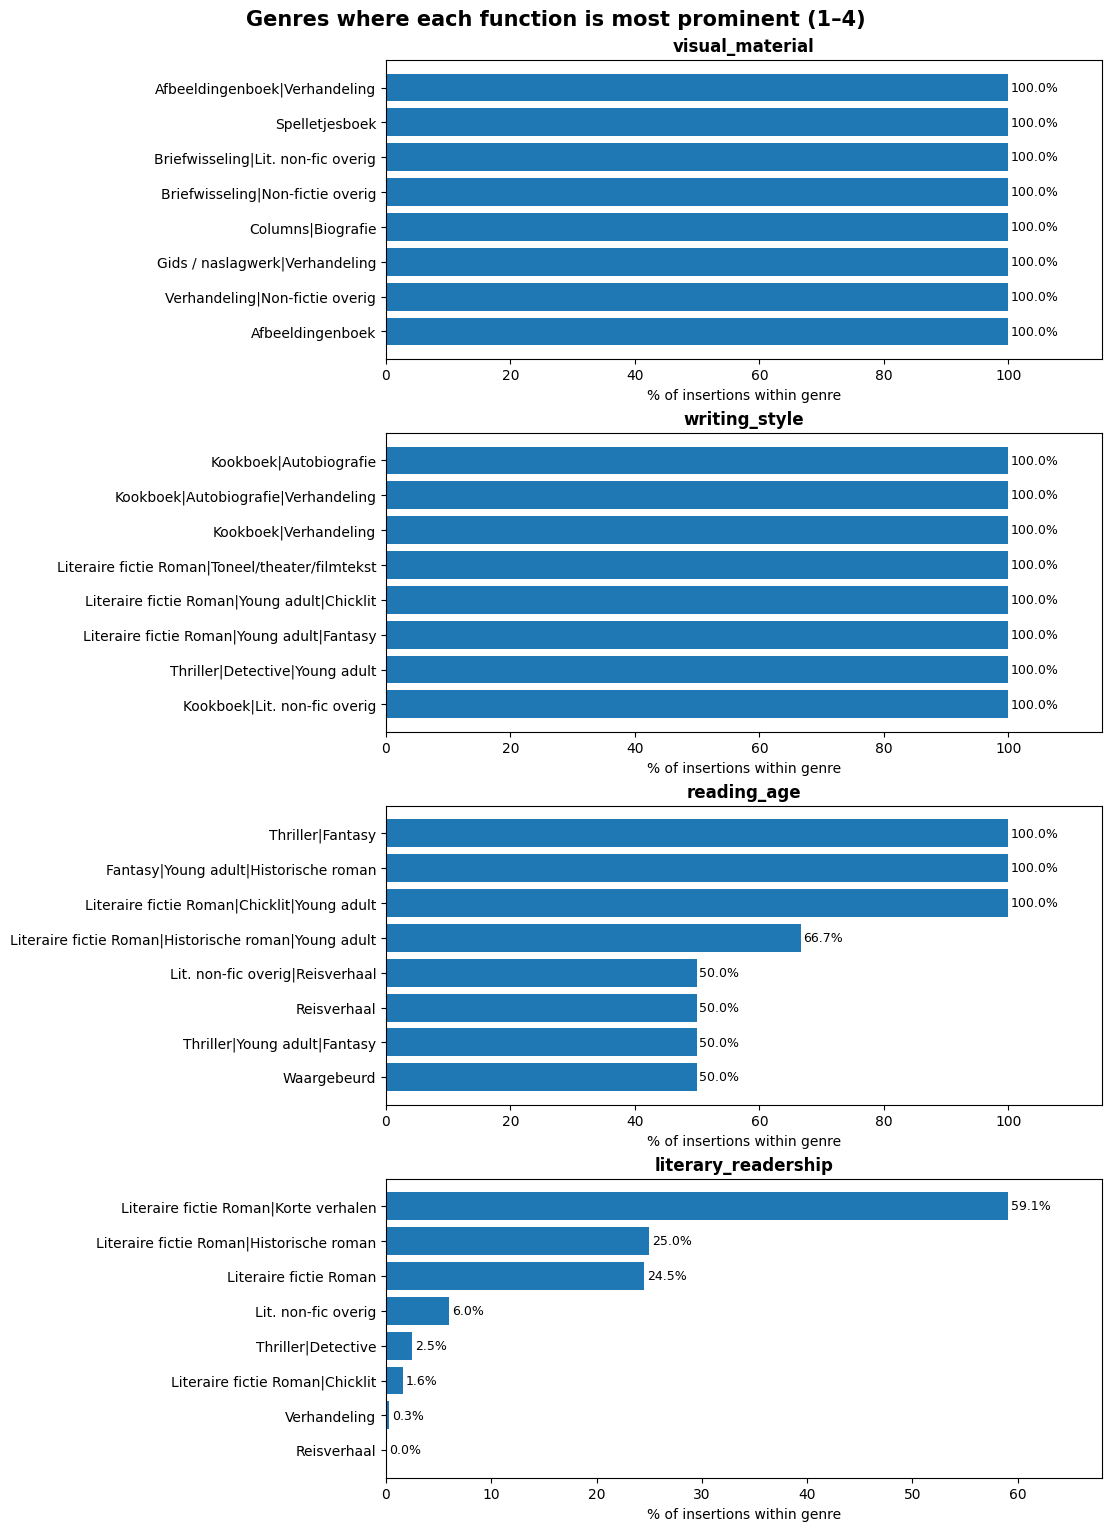

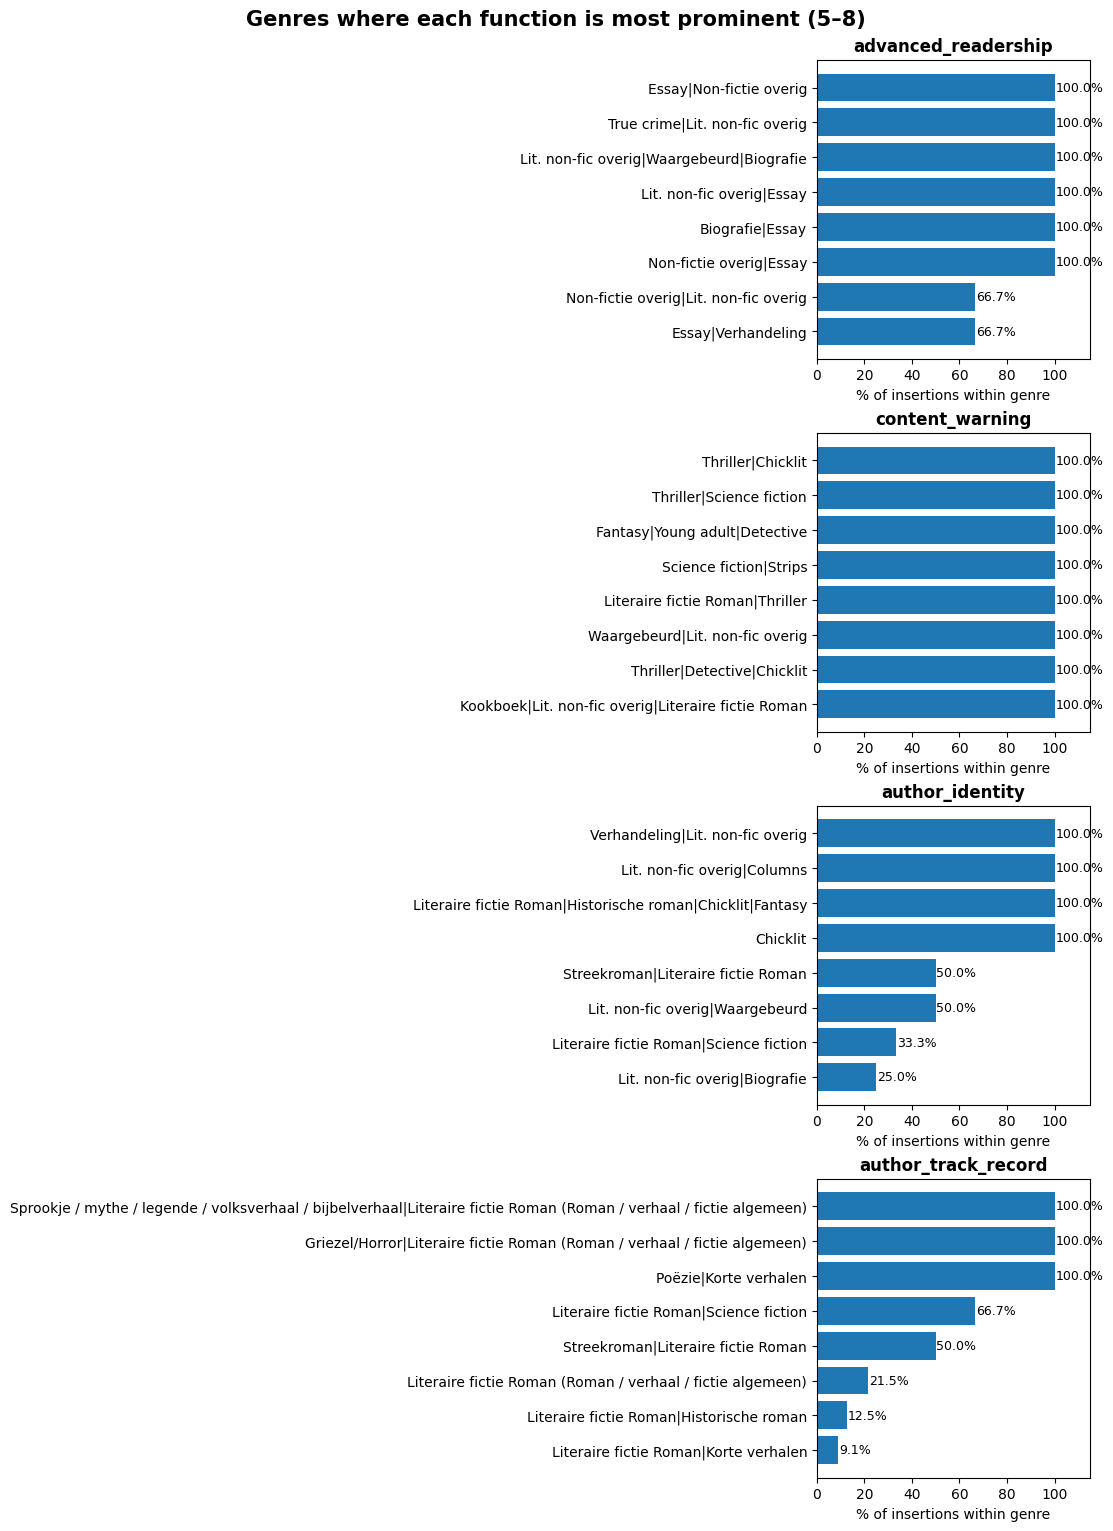

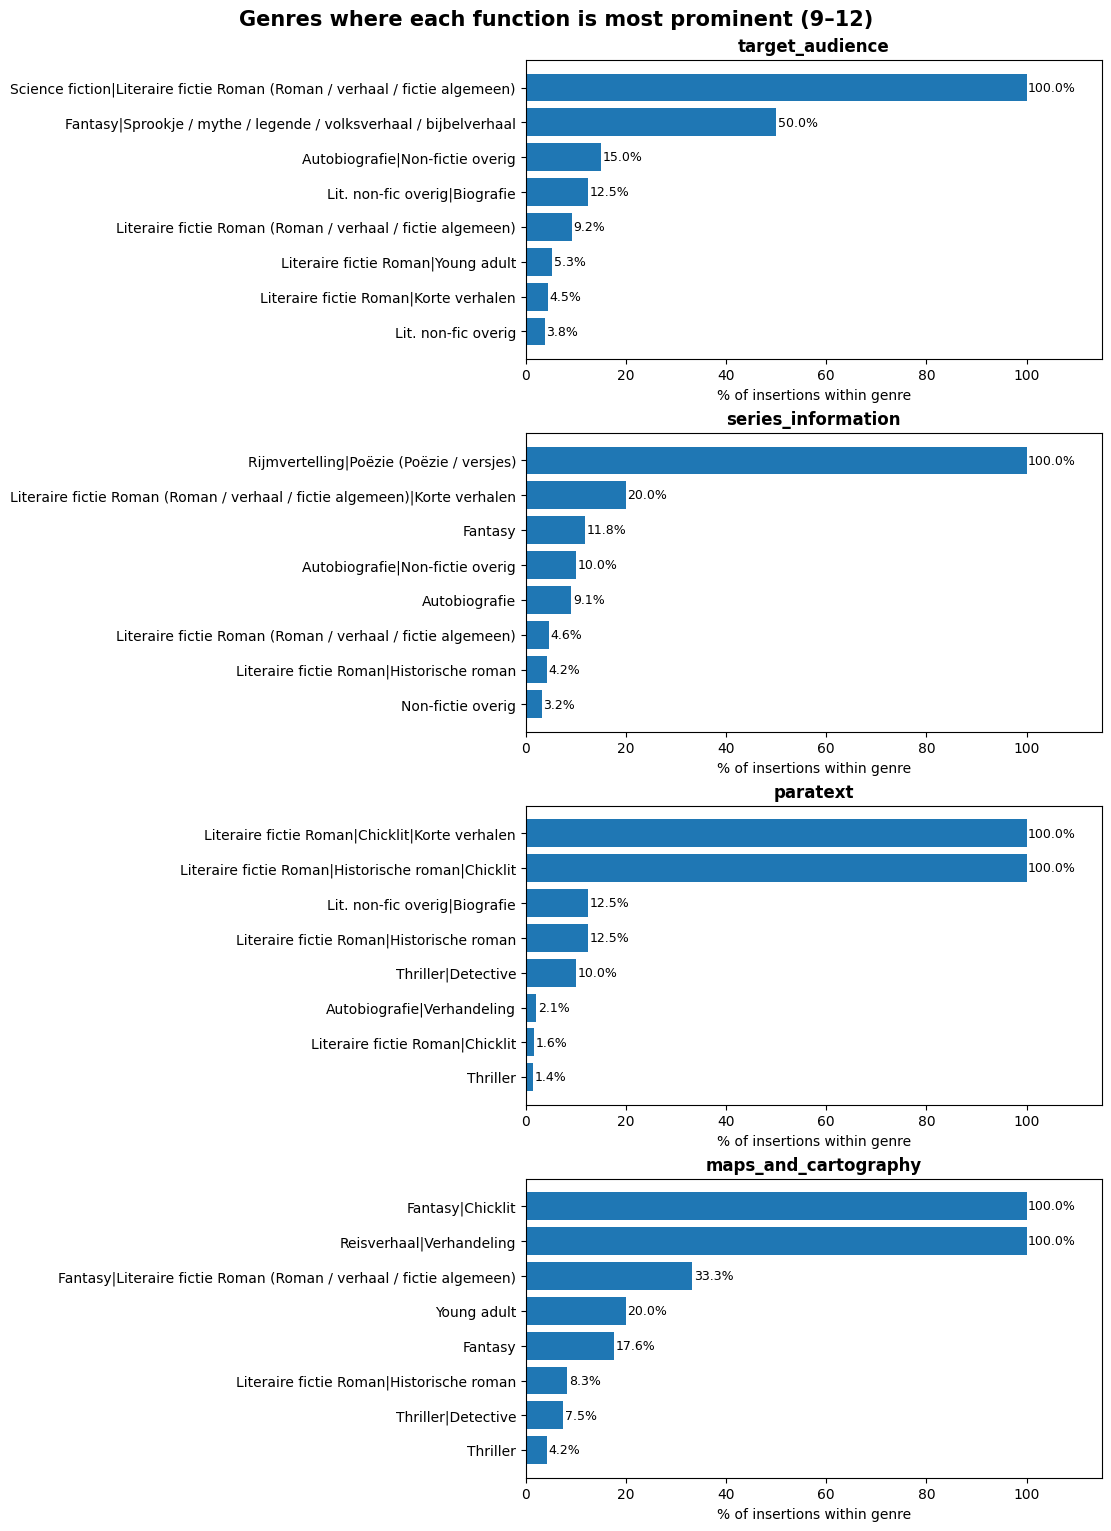

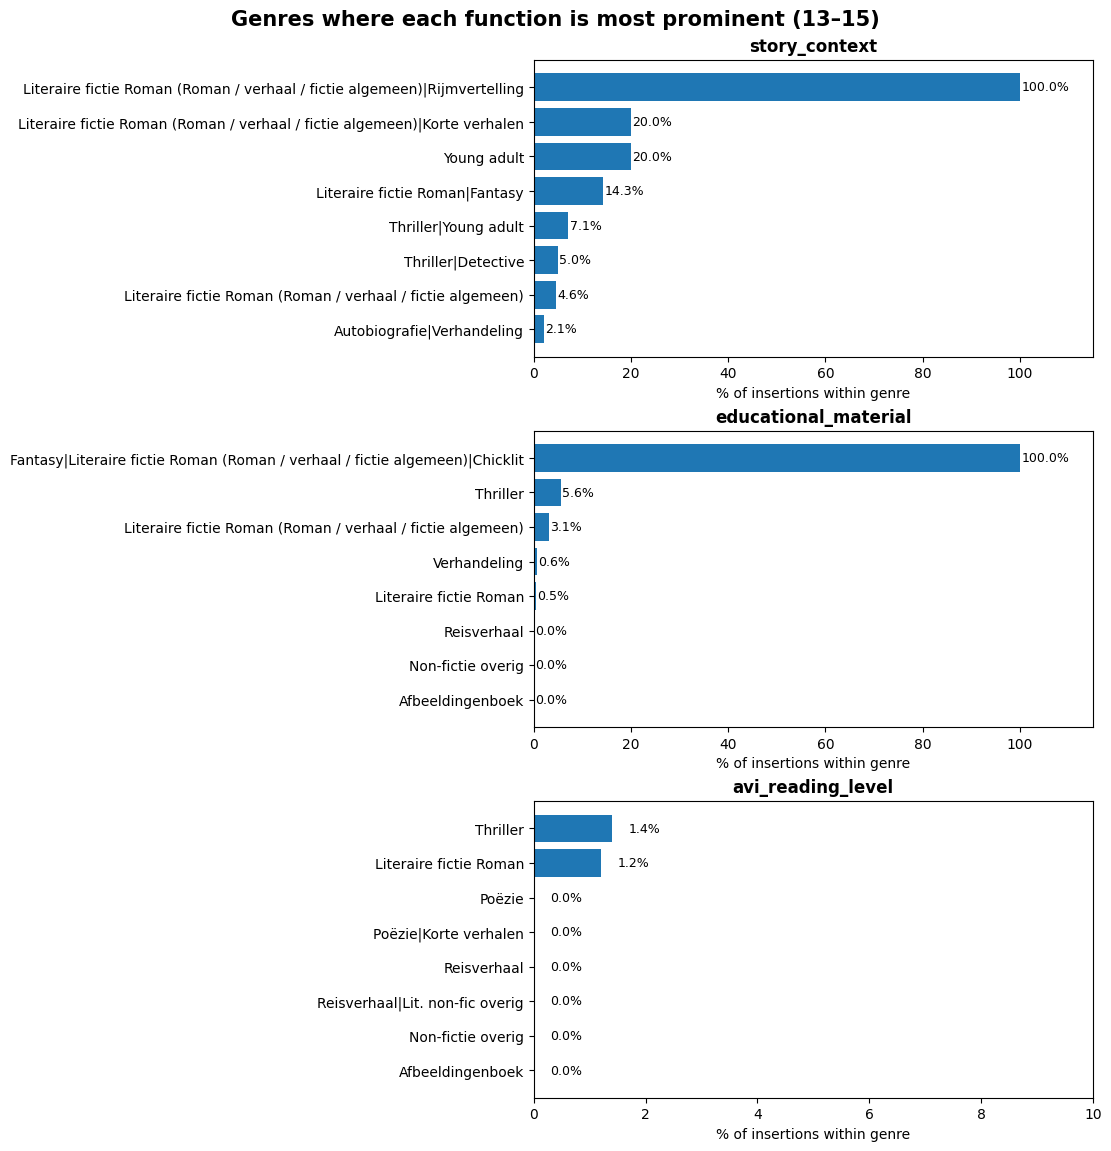

In [118]:
# Order functions by support
functions = (
    common_df
    .dropna(subset=["function"])
    .groupby("function")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

TOP_N = 8
FUNCTIONS_PER_FIGURE = 4

for start in range(0, len(functions), FUNCTIONS_PER_FIGURE):
    current_functions = functions[start:start + FUNCTIONS_PER_FIGURE]

    fig, axes = plt.subplots(
        len(current_functions),
        1,
        figsize=(11, 3.8 * len(current_functions)),
        constrained_layout=True
    )

    if len(current_functions) == 1:
        axes = [axes]

    for ax, function in zip(axes, current_functions):
        top = (
            genre_crosstab_pct
            .loc[function]
            .sort_values(ascending=False)
            .head(TOP_N)
            .sort_values()
        )

        ax.barh(top.index, top.values)

        ax.set_title(function, fontsize=12, fontweight="bold")
        ax.set_xlabel("% of insertions within genre")
        ax.set_xlim(0, max(top.max() * 1.15, 10))

        for i, value in enumerate(top.values):
            ax.text(
                value + 0.3,
                i,
                f"{value:.1f}%",
                va="center",
                fontsize=9
            )

    fig.suptitle(
        f"Genres where each function is most prominent ({start + 1}–{start + len(current_functions)})",
        fontsize=15,
        fontweight="bold"
    )

    plt.show()

### 8.2 Target Audience (VJ)

Analyze how communicative functions differ between adult, children's, and mixed-audience books. Percentages are normalized within each communicative function to show the relative distribution across target audiences.

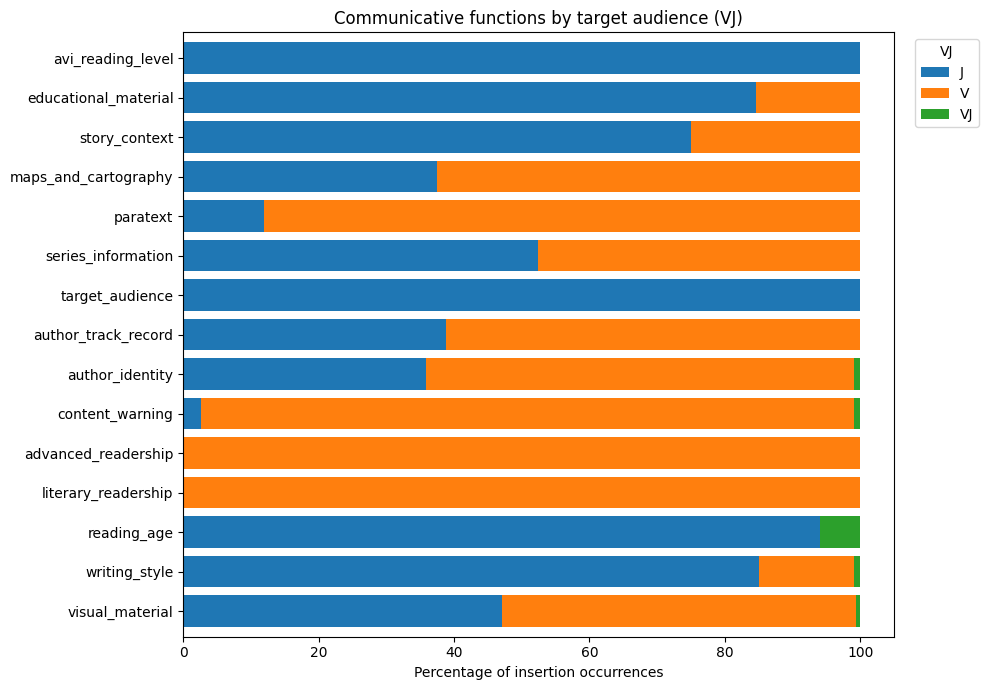

In [119]:

# If VJ is not yet in insert_df:
insert_df = insert_df.merge(
    df[["VJ"]],
    left_on="row_id",
    right_index=True,
    how="left"
)

# One row per insertion
vj_df = insert_df.dropna(subset=["function", "VJ"])

# Percentage distribution within each function
vj_pct = (
    pd.crosstab(
        vj_df["function"],
        vj_df["VJ"],
        normalize="index"
    ) * 100
)

# Order functions by support
function_order = (
    common_df
    .dropna(subset=["function"])
    .groupby("function")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

vj_pct = vj_pct.reindex(function_order)

ax = vj_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    width=0.8
)

ax.set_xlabel("Percentage of insertion occurrences")
ax.set_ylabel("")
ax.set_title("Communicative functions by target audience (VJ)")

plt.legend(title="VJ", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 8.3 Fiction vs. Non-fiction (FNF)

Compare the distribution of communicative functions between fiction and non-fiction books to identify function types that are characteristic of each category.

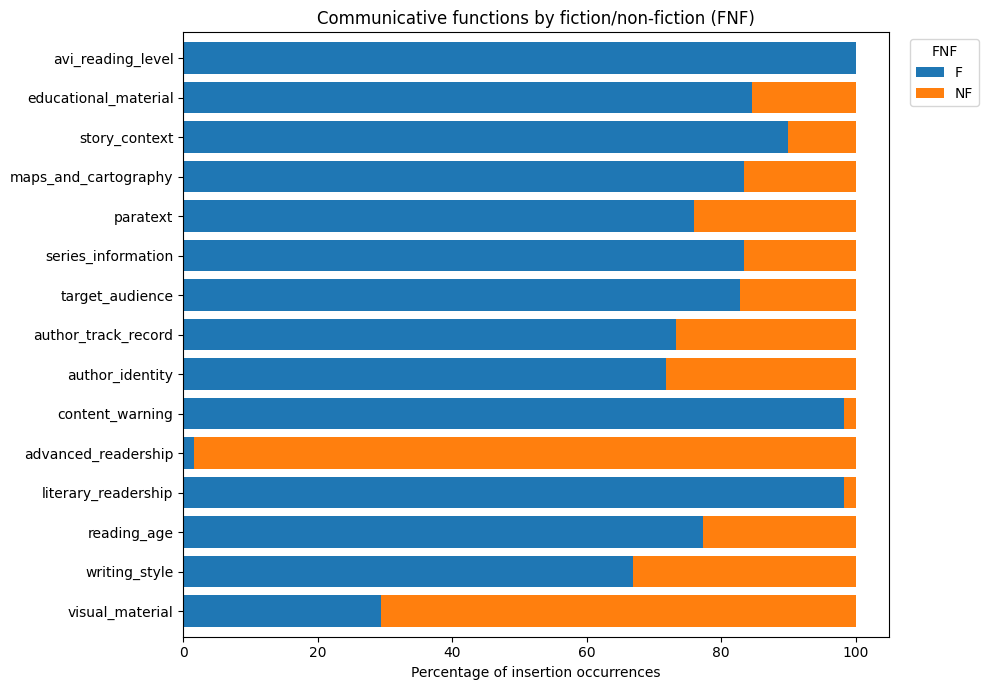

In [120]:
# If FNF is not yet in insert_df:
if "FNF" not in insert_df.columns:
    insert_df = insert_df.merge(
        df[["FNF"]],
        left_on="row_id",
        right_index=True,
        how="left"
    )

# One row per insertion
fnf_df = insert_df.dropna(subset=["function", "FNF"])

# Percentage distribution within each function
fnf_pct = (
    pd.crosstab(
        fnf_df["function"],
        fnf_df["FNF"],
        normalize="index"
    ) * 100
)

# Order functions by support
function_order = (
    common_df
    .dropna(subset=["function"])
    .groupby("function")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

fnf_pct = fnf_pct.reindex(function_order)

ax = fnf_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    width=0.8
)

ax.set_xlabel("Percentage of insertion occurrences")
ax.set_ylabel("")
ax.set_title("Communicative functions by fiction/non-fiction (FNF)")

plt.legend(title="FNF", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Summary Table

In [121]:
summary_table = (
    function_eval_df[
        [
            "function",
            "support",
            "support_pct",
            "avg_similarity",
            "backbone",
        ]
    ]
    .rename(columns={
        "function": "Function",
        "support": "Support",
        "support_pct": "Support (%)",
        "avg_similarity": "Avg. similarity",
        "backbone": "Representative backbone",
    })
    .sort_values("Support", ascending=False)
)

summary_table["Support (%)"] = summary_table["Support (%)"].map("{:.1f}%".format)
summary_table["Avg. similarity"] = summary_table["Avg. similarity"].map("{:.3f}".format)

display(summary_table)

,Function,Support,Support (%),Avg. similarity,Representative backbone
0,visual_material,470,18.6%,0.894,Met illustraties en foto's in kleur.
1,writing_style,448,17.7%,0.795,Vlot en lichtvoetig geschreven.
2,reading_age,321,12.7%,0.896,Geschikt voor lezers vanaf ca. <DATE>.
3,literary_readership,225,8.9%,0.941,Met name geschikt voor een literair lezerspubl...
4,advanced_readership,130,5.1%,0.917,Met name geschikt voor een geoefend lezerspubl...
5,content_warning,117,4.6%,0.832,Het boek bevat scènes met expliciete seks en e...
6,author_identity,103,4.1%,0.829,<PERSON> (<DATE>) is een <NATIONALITY> schrijver.
7,author_track_record,90,3.6%,0.808,Ze schreef meerdere boeken.
8,target_audience,58,2.3%,0.757,Om voor te lezen aan kinderen vanaf <DATE>.
9,series_information,42,1.7%,0.892,Het boek maakt deel uit van de serie '<TITLE>'.
